In [7]:
import time
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import csv

In [8]:
from google.colab import files

uploaded = files.upload()

Saving vertex_cover_results.csv to vertex_cover_results.csv
Saving file_vc45.txt to file_vc45.txt
Saving file_vc40.txt to file_vc40.txt
Saving file_vc35.txt to file_vc35.txt
Saving file_vc30.txt to file_vc30.txt
Saving file_vc25.txt to file_vc25.txt
Saving file_vc20.txt to file_vc20.txt
Saving file_vc15.txt to file_vc15.txt
Saving file_vc10.txt to file_vc10.txt


In [18]:
def greedy_vertex_cover(graph):

    matching = []
    used = set()

    for start, end in graph.edges():

        if start not in used and end not in used:
            matching.append((start, end))
            used.add(start)
            used.add(end)

    vertex_cover = set()

    for start, end in matching:
        vertex_cover.add(start)
        vertex_cover.add(end)

    return matching, sorted(vertex_cover)

In [20]:
results = pd.read_csv("vertex_cover_results.csv")

print("P1 Results:")
display(results)

P1 Results:


,"(n, m)",BF Size,BF Time
0,"(10, 10)",4,0.001692
1,"(10, 15)",6,0.003075
2,"(10, 20)",6,0.001261
3,"(10, 25)",7,0.003343
4,"(10, 30)",6,0.001100
5,"(10, 35)",7,0.001824
6,"(10, 40)",8,0.001768
7,"(10, 45)",9,0.002094


In [21]:
n = 10

p2_results = []

for m in range(10, 46, 5):

    file_name = "file_vc" + str(m) + ".txt"

    graph = nx.Graph()

    with open(file_name, "r") as file:
        for line in file:
            start, end = line.strip().split(",")
            graph.add_edge(int(start),int(end))

    graph.add_nodes_from(range(1, n + 1))


    start_time = time.time()
    matching, vertex_cover = greedy_vertex_cover(graph)
    end_time = time.time()
    running_time = end_time - start_time

    pair = "(" + str(n) + ", " + str(m) + ")"
    p1_row = results[results["(n, m)"] == pair]
    optimal_size = int(p1_row.iloc[0]["BF Size"])

    matching_size = len(matching)
    cover_size = len(vertex_cover)
    approximation_factor = cover_size / optimal_size

    print("\nVertices :", n)
    print("Edges :", m)
    print("Matching :", matching)
    print("Matching Size :", matching_size)
    print("Computed Vertex Cover :", vertex_cover)
    print("Computed Cover Size :", cover_size)
    print("Optimal Cover Size :", optimal_size)
    print("Approximation Factor :", approximation_factor)
    print("Running Time :", running_time)

    p2_results.append([pair,matching_size,cover_size,approximation_factor,running_time])


Vertices : 10
Edges : 10
Matching : [(3, 10), (2, 8), (7, 6), (5, 1)]
Matching Size : 4
Computed Vertex Cover : [1, 2, 3, 5, 6, 7, 8, 10]
Computed Cover Size : 8
Optimal Cover Size : 4
Approximation Factor : 2.0
Running Time : 5.7220458984375e-05

Vertices : 10
Edges : 15
Matching : [(2, 7), (6, 8), (4, 1), (10, 5), (9, 3)]
Matching Size : 5
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Computed Cover Size : 10
Optimal Cover Size : 6
Approximation Factor : 1.6666666666666667
Running Time : 4.57763671875e-05

Vertices : 10
Edges : 20
Matching : [(9, 8), (6, 5), (1, 2), (10, 7)]
Matching Size : 4
Computed Vertex Cover : [1, 2, 5, 6, 7, 8, 9, 10]
Computed Cover Size : 8
Optimal Cover Size : 6
Approximation Factor : 1.3333333333333333
Running Time : 3.886222839355469e-05

Vertices : 10
Edges : 25
Matching : [(10, 1), (4, 8), (6, 5), (2, 9)]
Matching Size : 4
Computed Vertex Cover : [1, 2, 4, 5, 6, 8, 9, 10]
Computed Cover Size : 8
Optimal Cover Size : 7
Approximation Factor : 1.

In [22]:
p2_table = pd.DataFrame(p2_results,columns=["(n, m)","Matching Size","Computed Vertex Cover Size","Approximation Factor","P2 Running Time"])
print("P2 Results:")
display(p2_table)

P2 Results:


,"(n, m)",Matching Size,Computed Vertex Cover Size,Approximation Factor,P2 Running Time
0,"(10, 10)",4,8,2.000000,0.000057
1,"(10, 15)",5,10,1.666667,0.000046
2,"(10, 20)",4,8,1.333333,0.000039
3,"(10, 25)",4,8,1.142857,0.000028
4,"(10, 30)",4,8,1.333333,0.000026
5,"(10, 35)",4,8,1.142857,0.000024
6,"(10, 40)",5,10,1.250000,0.000035
7,"(10, 45)",5,10,1.111111,0.000025


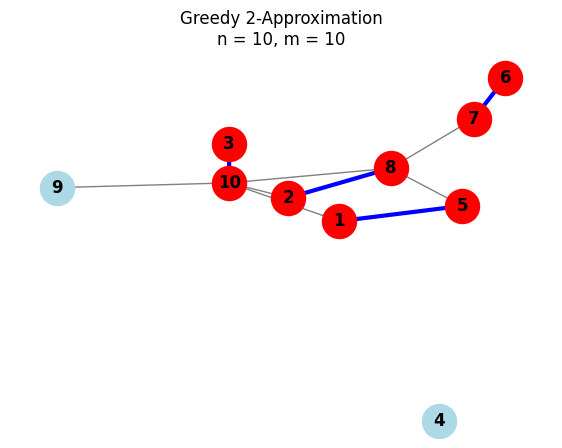

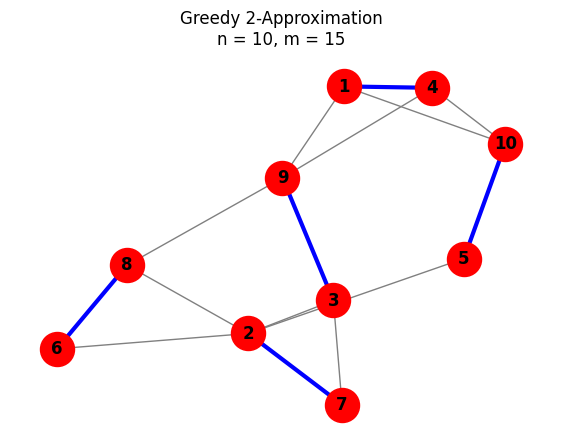

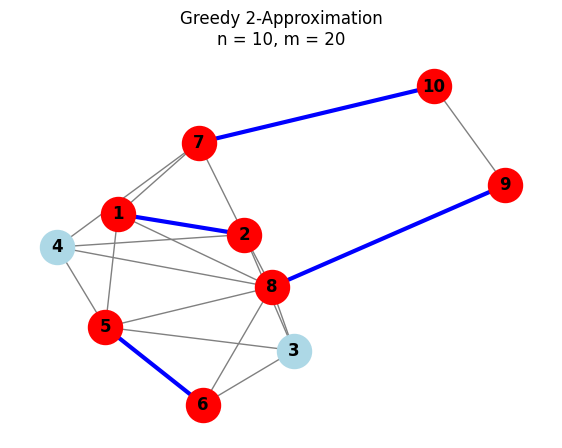

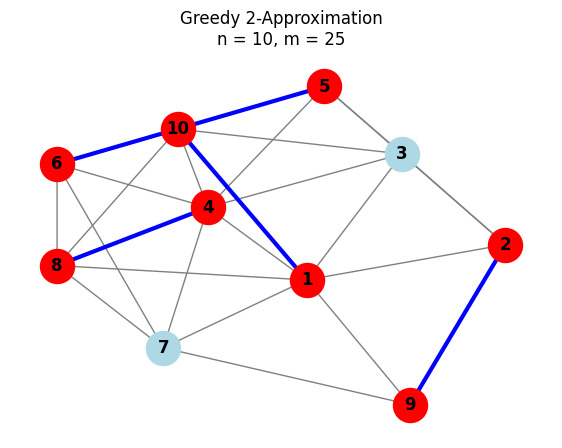

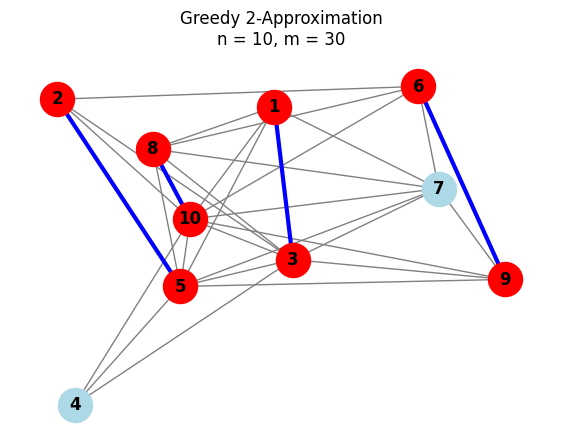

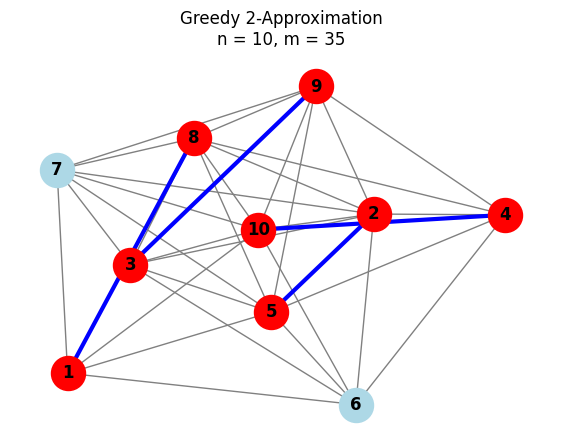

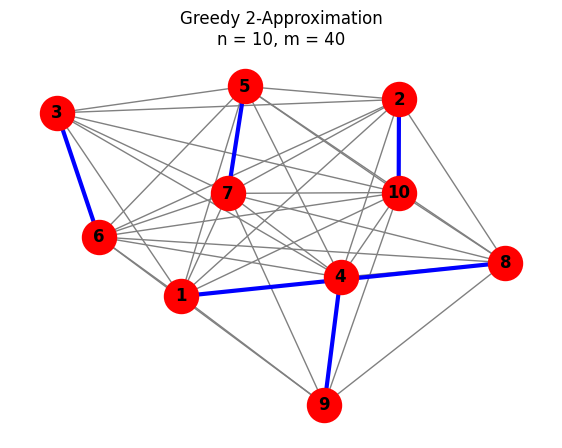

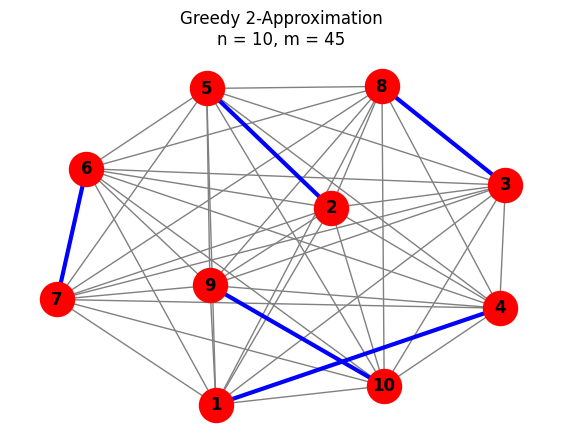

In [23]:
for m in range(10, 46, 5):

    file_name = "file_vc" + str(m) + ".txt"
    graph = nx.Graph()

    with open(file_name, "r") as file:
        for line in file:
            start, end = line.strip().split(",")
            graph.add_edge(int(start), int(end))

    graph.add_nodes_from(range(1, n + 1))

    matching, vertex_cover = greedy_vertex_cover(graph)

    pos = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=(7, 5))

    nx.draw_networkx_edges(graph,pos,edge_color="gray")

    normal_nodes = [node for node in graph.nodes()if node not in vertex_cover]

    nx.draw_networkx_nodes(graph,pos,nodelist=normal_nodes,node_color="lightblue",node_size=600)

    nx.draw_networkx_nodes(graph,pos,nodelist=vertex_cover,node_color="red",node_size=600)

    nx.draw_networkx_edges(graph,pos,edgelist=matching,edge_color="blue",width=3)

    nx.draw_networkx_labels(graph,pos,font_weight="bold")

    plt.title("Greedy 2-Approximation\n"+ "n = " + str(n)+ ", m = " + str(m))
    plt.axis("off")
    plt.savefig("P2_graph_" + str(m) + "_edges.png",bbox_inches="tight")
    plt.show()
    plt.close()

In [24]:
results = results.rename(columns={"BF Size": "P1 Cover Size","BF Time": "P1 Running Time"})

p2_table = pd.DataFrame(p2_results,columns=["(n, m)","Matching Size","Computed Vertex Cover Size","Approximation Factor","P2 Running Time"])

updated_results = results.merge(p2_table,on="(n, m)",how="left")

updated_results.to_csv("vertex_cover_results.csv",index=False)
print("Updated results saved to vertex_cover_results.csv")
display(updated_results)

Updated results saved to vertex_cover_results.csv


,"(n, m)",P1 Cover Size,BF Time,Matching Size,Computed Vertex Cover Size,Approximation Factor,P2 Running Time
0,"(10, 10)",4,0.001692,4,8,2.000000,0.000057
1,"(10, 15)",6,0.003075,5,10,1.666667,0.000046
2,"(10, 20)",6,0.001261,4,8,1.333333,0.000039
3,"(10, 25)",7,0.003343,4,8,1.142857,0.000028
4,"(10, 30)",6,0.001100,4,8,1.333333,0.000026
5,"(10, 35)",7,0.001824,4,8,1.142857,0.000024
6,"(10, 40)",8,0.001768,5,10,1.250000,0.000035
7,"(10, 45)",9,0.002094,5,10,1.111111,0.000025
